In [1]:
import re
import pandas as pd
import os, sys
from IPython.core.debugger import set_trace
from plotnine import *
import numpy as np
from scipy import stats
import arviz as az

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html


In [2]:
# This code from Qiqi extracts the date, origin, and destination of each markov jump
# With a couple additions from me (noted by comments)
# Repository DOI: 10.5281/zenodo.10480799

def extractJumpTrees(filedir, mrsd, burnin,outputFiledir):
    k=0
    jumplist=[]

    with open(filedir) as jumpTrees:
        # if the input file has the whole information from BEAST, i.e. other tree information at the start, then 
        # the following codes are activated:
        for line in jumpTrees:
            if line.startswith('tree STATE_'):
                break
                
        for line in jumpTrees:
            if line.startswith('End'):
                break
                set_trace()
                
            k+=1
            state = re.search(r"\d+(?=\s)",line).group(0)
            # jumps = re.findall(r"\{(\d+\.\d+\,\w+\,\w+)\}",line)
            jumps = re.findall(r"\{(\d+\.\d+,\s*[\w-]+,\s*[\w-]+)\}", line) # I updated this line to get the correct REGEX
            jumphistory = [re.split(",",jump,3) for jump in jumps]
            df = pd.DataFrame(jumphistory,columns=['height','origin','destination'])
            df['treeNumber'] = k
            df['date'] = mrsd
            df['date'] = df['date']- [float(x) for x in df['height']]
            df['year'] = df['date'].astype(str).str.split(".", expand = True)[0] # I added year because I want to calculate the number of Markov jumps per year
            jumplist.extend([df])
            
            if line.endswith(';'):
                continue
            
    allTreesJumps = pd.concat(jumplist,axis=0)
    maxTreeNum = allTreesJumps.max()['treeNumber']
    allTreesJumps_bi = allTreesJumps[allTreesJumps['treeNumber'] > int(burnin*maxTreeNum)]
    allTreesJumps_bi.to_csv(outputFiledir, sep = "\t")

    return(allTreesJumps_bi)

In [3]:
# filedir = "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/run_2/A6_concat-genome_traits_gnl-eu_2026-03-10.region.history.trees"
# filedir = "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/A6_concat-genome_traits_2026-03-10_region-history-901combined.trees"
filedir = "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_901combined.region.history.trees"

In [4]:
# treejumps = extractJumpTrees(filedir, 2025.8575342465754, 0.1, "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/run_2/region_history.tsv")
# treejumps = extractJumpTrees(filedir, 2025.8575342465754, 0.0, "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/region-history_901trees.tsv")
treejumps = extractJumpTrees(filedir, 2026.0520547945205, 0.0, "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/region-history_901trees.tsv")

In [10]:
continent_dict = {"north-canada":"northamerica",
                  "northeast-us":"northamerica",
                  "northwest-us":"northamerica",
                  "asia":"asia",
                  "east-canada":"northamerica",
                  "europe":"europe",
                  "ancestor":"ancestor"
                 }

labels_dict = {"northamerica" : "North America",
              "europe":"Europe",
              "asia":"Asia",
              "east-canada":"east Canada",
              "northeast-us":"New England",
              "north-canada":"north Canada",
              "northwest-us":"Pacific Northwest"
              }

In [11]:
treejumps["combo"] = treejumps["origin"] + "," + treejumps["destination"]
treejumps["originContinent"] = treejumps["origin"].map(continent_dict)
treejumps["destContinent"] = treejumps["destination"].map(continent_dict)
treejumps["comboContinent"] = treejumps["originContinent"] + "," + treejumps["destContinent"]

In [12]:
treejumps.head()

,height,origin,destination,treeNumber,date,year,combo,originContinent,destContinent,comboContinent
0,2.3117501639275924,europe,east-canada,1,2023.740305,2023,"europe,east-canada",europe,northamerica,"europe,northamerica"
1,0.9644626137381878,europe,east-canada,1,2025.087592,2025,"europe,east-canada",europe,northamerica,"europe,northamerica"
2,1.1887521674868922,europe,east-canada,1,2024.863303,2024,"europe,east-canada",europe,northamerica,"europe,northamerica"
3,0.7980644853082418,europe,asia,1,2025.253990,2025,"europe,asia",europe,asia,"europe,asia"
4,1.20215522677016,europe,east-canada,1,2024.849900,2024,"europe,east-canada",europe,northamerica,"europe,northamerica"


In [13]:
print(treejumps["combo"].value_counts())

combo
east-canada,northeast-us     12344
europe,east-canada            8593
east-canada,europe            3807
europe,asia                   1803
northeast-us,east-canada      1593
north-canada,northwest-us     1110
northeast-us,north-canada      618
east-canada,north-canada       502
east-canada,northwest-us       478
northeast-us,northwest-us      237
northwest-us,north-canada       39
northeast-us,europe             28
north-canada,east-canada        17
europe,northwest-us             15
north-canada,northeast-us       10
northwest-us,east-canada         8
europe,north-canada              7
east-canada,asia                 7
northwest-us,europe              5
europe,northeast-us              4
asia,east-canada                 4
northwest-us,northeast-us        3
north-canada,europe              3
north-canada,asia                3
asia,northwest-us                3
northwest-us,asia                2
northeast-us,asia                2
asia,north-canada                2
asia,northeast

In [14]:
# To plot the number of Markov Jumps from one region to another across the posterior

transition_dense_rows = []

for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
    if combo == "northamerica,northamerica":
        pass
    else:
        transition_dense_rows.append({"tree":tree, "combo": combo, "no_transitions":len(df)})

transition_dense = pd.DataFrame(transition_dense_rows)
transition_dense["labels"] = transition_dense["combo"].str.split(",",expand = True)[0].map(labels_dict) + " - " + transition_dense["combo"].str.split(",",expand = True)[1].map(labels_dict)

In [15]:
transition_dense_means = transition_dense.groupby("combo")["no_transitions"].mean()
transition_dense_means = pd.DataFrame(transition_dense_means).reset_index().rename({"no_transitions":"mean_transitions"}, axis = 1)
transition_dense_means["label"] = "Mean = " + transition_dense_means["mean_transitions"].round(2).astype(str)
transition_dense_means["x"] = transition_dense_means["mean_transitions"] + 0.5
transition_dense_means["colors"] = transition_dense_means["combo"].str.split(",", expand = True)[0].map(labels_dict) + " - " + transition_dense_means["combo"].str.split(",",expand = True)[1].map(labels_dict)

In [16]:
transition_dense_hpd = transition_dense.groupby("combo")["no_transitions"].apply(lambda col: az.hdi(col.values, hdi_prob=0.95)).apply(pd.Series)
print(transition_dense_hpd)

                     0   1
combo                     
asia,northamerica    1   1
europe,asia          2   2
europe,northamerica  9  11
northamerica,asia    1   2
northamerica,europe  3   5


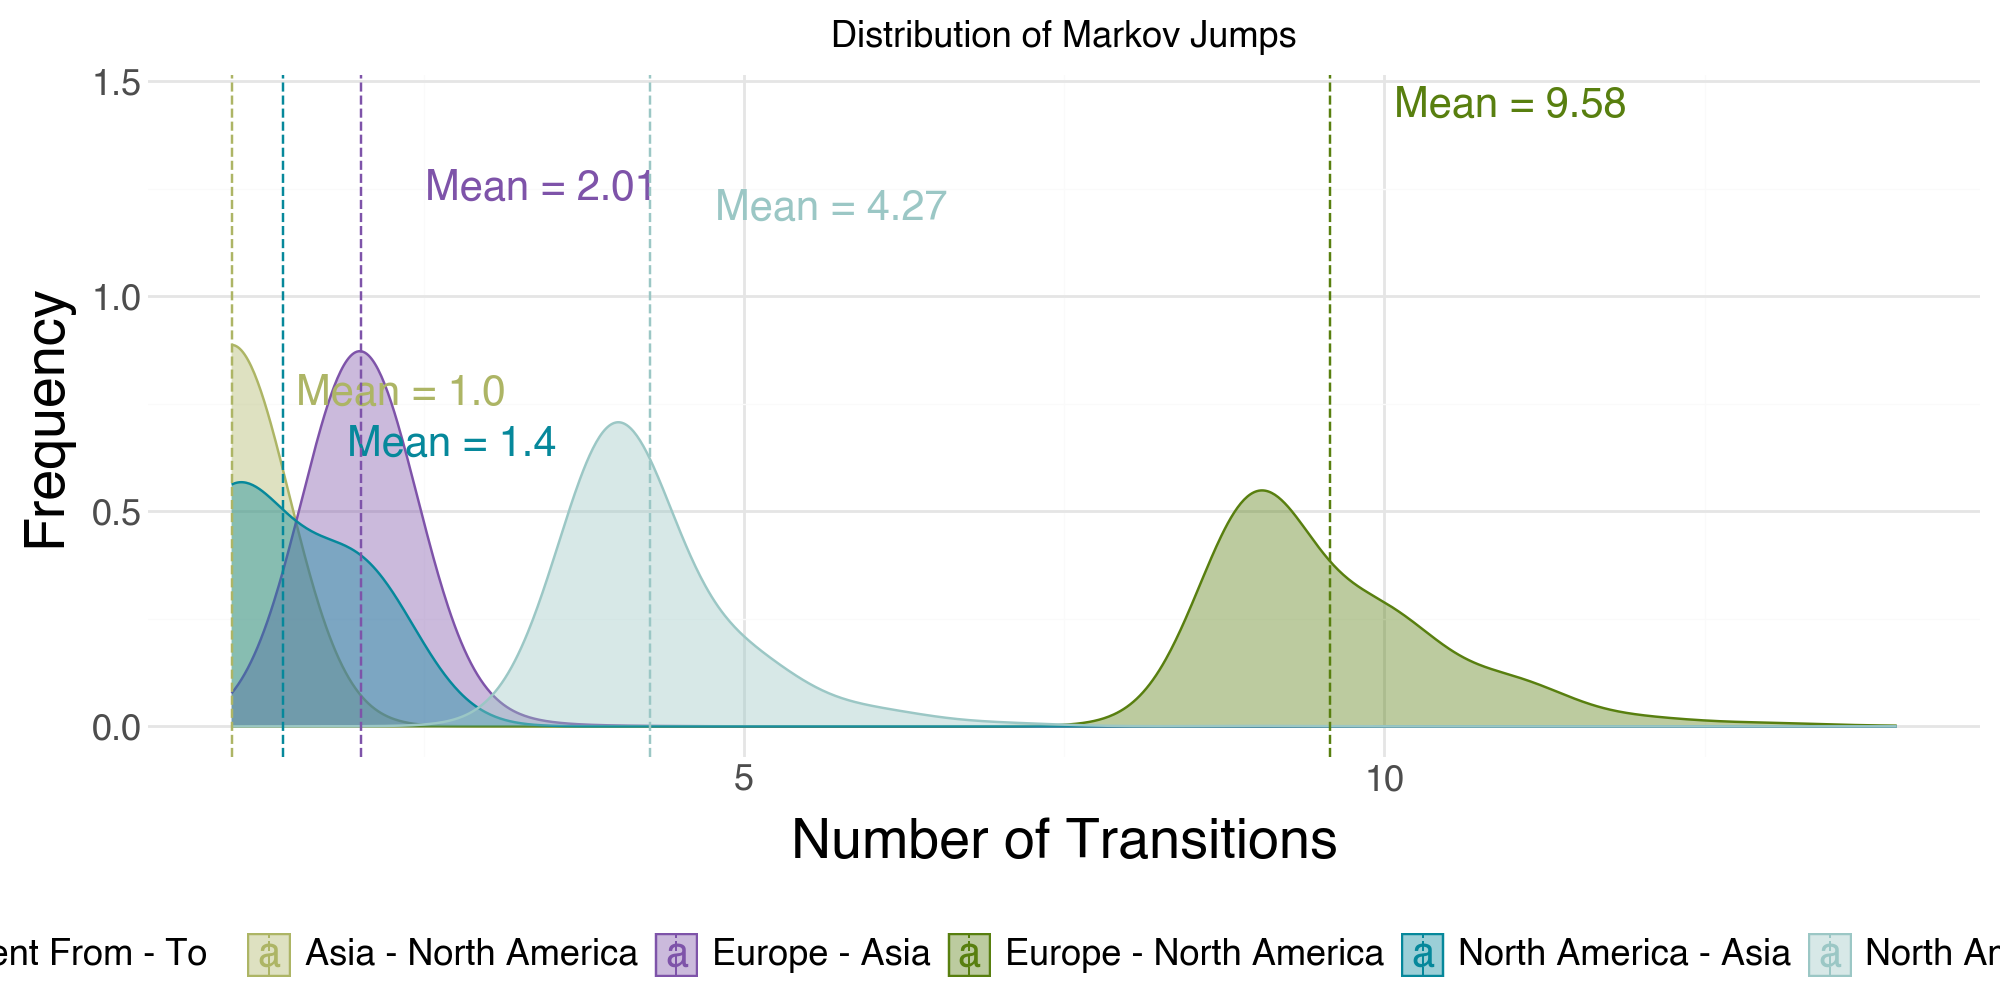

In [22]:
colors = {"Europe - Asia":"#7E53A9",
          "Europe - North America":"#587F0F",
          "North America - Asia":"#06889B",
          "North America - Europe":"#9BC7C5",
          "Asia - Europe":"#AE8853",
          "Asia - North America":"#ADB565"
         }


plt1 = (
    ggplot()
    + geom_density(transition_dense, aes(x = "no_transitions", color = "labels", fill = "labels"), alpha=0.4, bw = 0.45) # default bandwidth (bw) looks to be about 0.15-0.2
    + geom_text(transition_dense_means, aes(x="x", y=1, label="label", color = "colors"),size=15, ha='left', position=position_jitter(width=0.0,height=0.5))
    + geom_vline(transition_dense_means, aes(xintercept = "mean_transitions", color = "colors"), linetype = "dashed", size = 0.5)
    + labs(title='Distribution of Markov Jumps',x='Number of Transitions',y='Frequency', color='Continent From - To', fill='Continent From - To')
    # + facet_wrap("labels")
    + scale_fill_manual(colors)
    + scale_color_manual(colors)
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=13),
           legend_direction="horizontal", legend_position="bottom")
)

plt1.show()

In [203]:
plt1.save("./SERAPHIM/output_plots/mj_region_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_region_across_posterior.png


In [12]:
# To plot the number of trans-atlantic and within North America Markov Jumps 

trans_cis_rows = []

for (combo, tree), df in treejumps.groupby(["combo","treeNumber"]):
    trans_cis_rows.append({"tree":tree, "combo": combo, "no_transitions":len(df)})

trans_cis_dense = pd.DataFrame(trans_cis_rows)

trans_cis_dict = {"europe,east-canada":"Trans-Atlantic",
                  "east-canada,new-england":"Along Atlantic Coast",
                  "east-canada,europe":"Trans-Atlantic",
                  "north-canada,pacific-northwest":"Across North America",
                  "new-england,north-canada":"Across North America",
                  "east-canada,north-canada":"Across North America",
                  "new-england,east-canada":"Along Atlantic Coast",
                  "new-england,pacific-northwest":"Across North America",
                  "new-england,europe":"Trans-Atlantic",
                  "europe,pacific-northwest":"Trans-Atlantic",
                  "europe,north-canada":"Trans-Atlantic",
                  "pacific-northwest,north-canada":"Across North America",
                  "north-canada,new-england":"Across North America",
                  "europe,new-england":"Trans-Atlantic",
                  "north-canada,east-canada":"Across North America",
                  "east-canada,pacific-northwest":"Across North America",
                  "north-canada,europe":"Trans-Atlantic",
                  "pacific-northwest,east-canada":"Across North America"
                 }

trans_cis_dense["trans-cis"] = trans_cis_dense["combo"].map(trans_cis_dict).fillna("Other")

# trans_cis_dense_filtered = trans_cis_dense[trans_cis_dense["no_transitions"] > 10] # I have ~800 trees, so maybe I want to do transitions that occur >100 times?

In [13]:
trans_cis_dense_means = trans_cis_dense.groupby("trans-cis")["no_transitions"].mean()
trans_cis_dense_means = pd.DataFrame(trans_cis_dense_means).reset_index().rename({"no_transitions":"mean_transitions"}, axis = 1)
trans_cis_dense_means["x"] = trans_cis_dense_means["mean_transitions"] + 0.5
trans_cis_dense_means["label"] = "Mean = " + trans_cis_dense_means["mean_transitions"].round(2).astype(str)

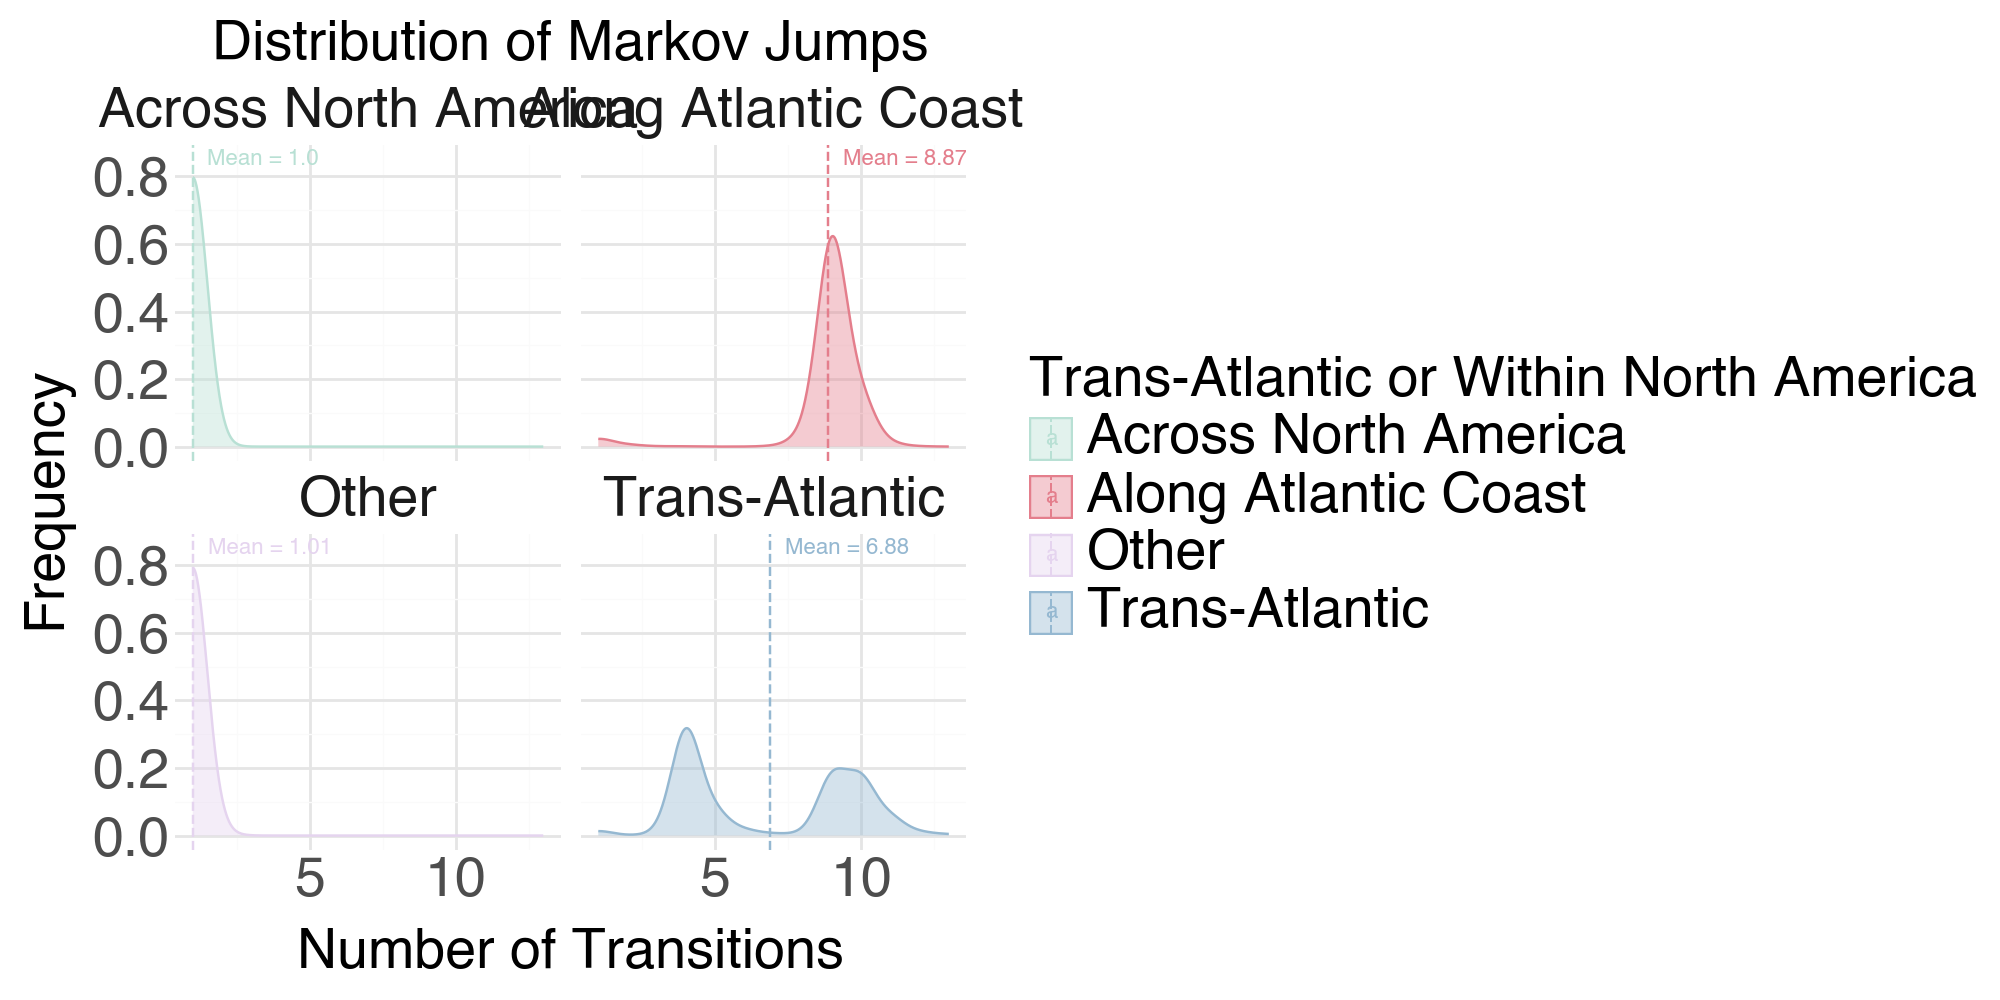

In [183]:
colors2 = {"Trans-Atlantic":"#95b8d1",
          "Across North America":"#b8e0d4",
          "Along Atlantic Coast":"#e47e8c",
          "Other":"#e5d4ef"
          }

plt2 = (
    ggplot()
    + geom_density(trans_cis_dense, aes(x = "no_transitions", color = "trans-cis", fill = "trans-cis"), alpha=0.4, bw = 0.5) # default bandwidth (bw) looks to be about 0.15-0.2
    + geom_text(trans_cis_dense_means, aes(x = "x", y = 0.85, label = "label", color = "trans-cis"), size=8, ha='left')
    + geom_vline(trans_cis_dense_means, aes(xintercept = "mean_transitions", color = "trans-cis"), linetype = "dashed", size = 0.5)
    + labs(title='Distribution of Markov Jumps',x='Number of Transitions',y='Frequency', color='Trans-Atlantic or Within North America', fill='Trans-Atlantic or Within North America')
    + facet_wrap("trans-cis")
    + scale_fill_manual(colors2)
    + scale_color_manual(colors2)
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
)

plt2.show()

In [184]:
plt2.save("./SERAPHIM/output_plots/mj_trans-cis_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_trans-cis_across_posterior.png


In [23]:
# To plot the cumulative number of Markov Jumps from Europe to North America and back over time

cumul_jumps_rows = []

mask = ["europe,northamerica","northamerica,europe"]

for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
    if combo in mask:
        df["month_bin"] = np.floor(df["date"] * 12) / 12
        df = df.sort_values("month_bin")
        df["cumcount"] = range(1, len(df) + 1) # According to ChatGPT, this line creates a sequence, starting from 1, that counts incidence over time
        columns = ["treeNumber", "date", "month_bin", "comboContinent", "cumcount"]
        cumul_jumps_rows.append(df.loc[:, columns])
    else:
       pass


cumul_jumps = pd.concat(cumul_jumps_rows)

In [24]:
# It is hard to read the cloud of the posterior 
# So I took the mean cumulative count per transition per month

medians = cumul_jumps.groupby(["month_bin", "comboContinent"])["cumcount"].median().reset_index()

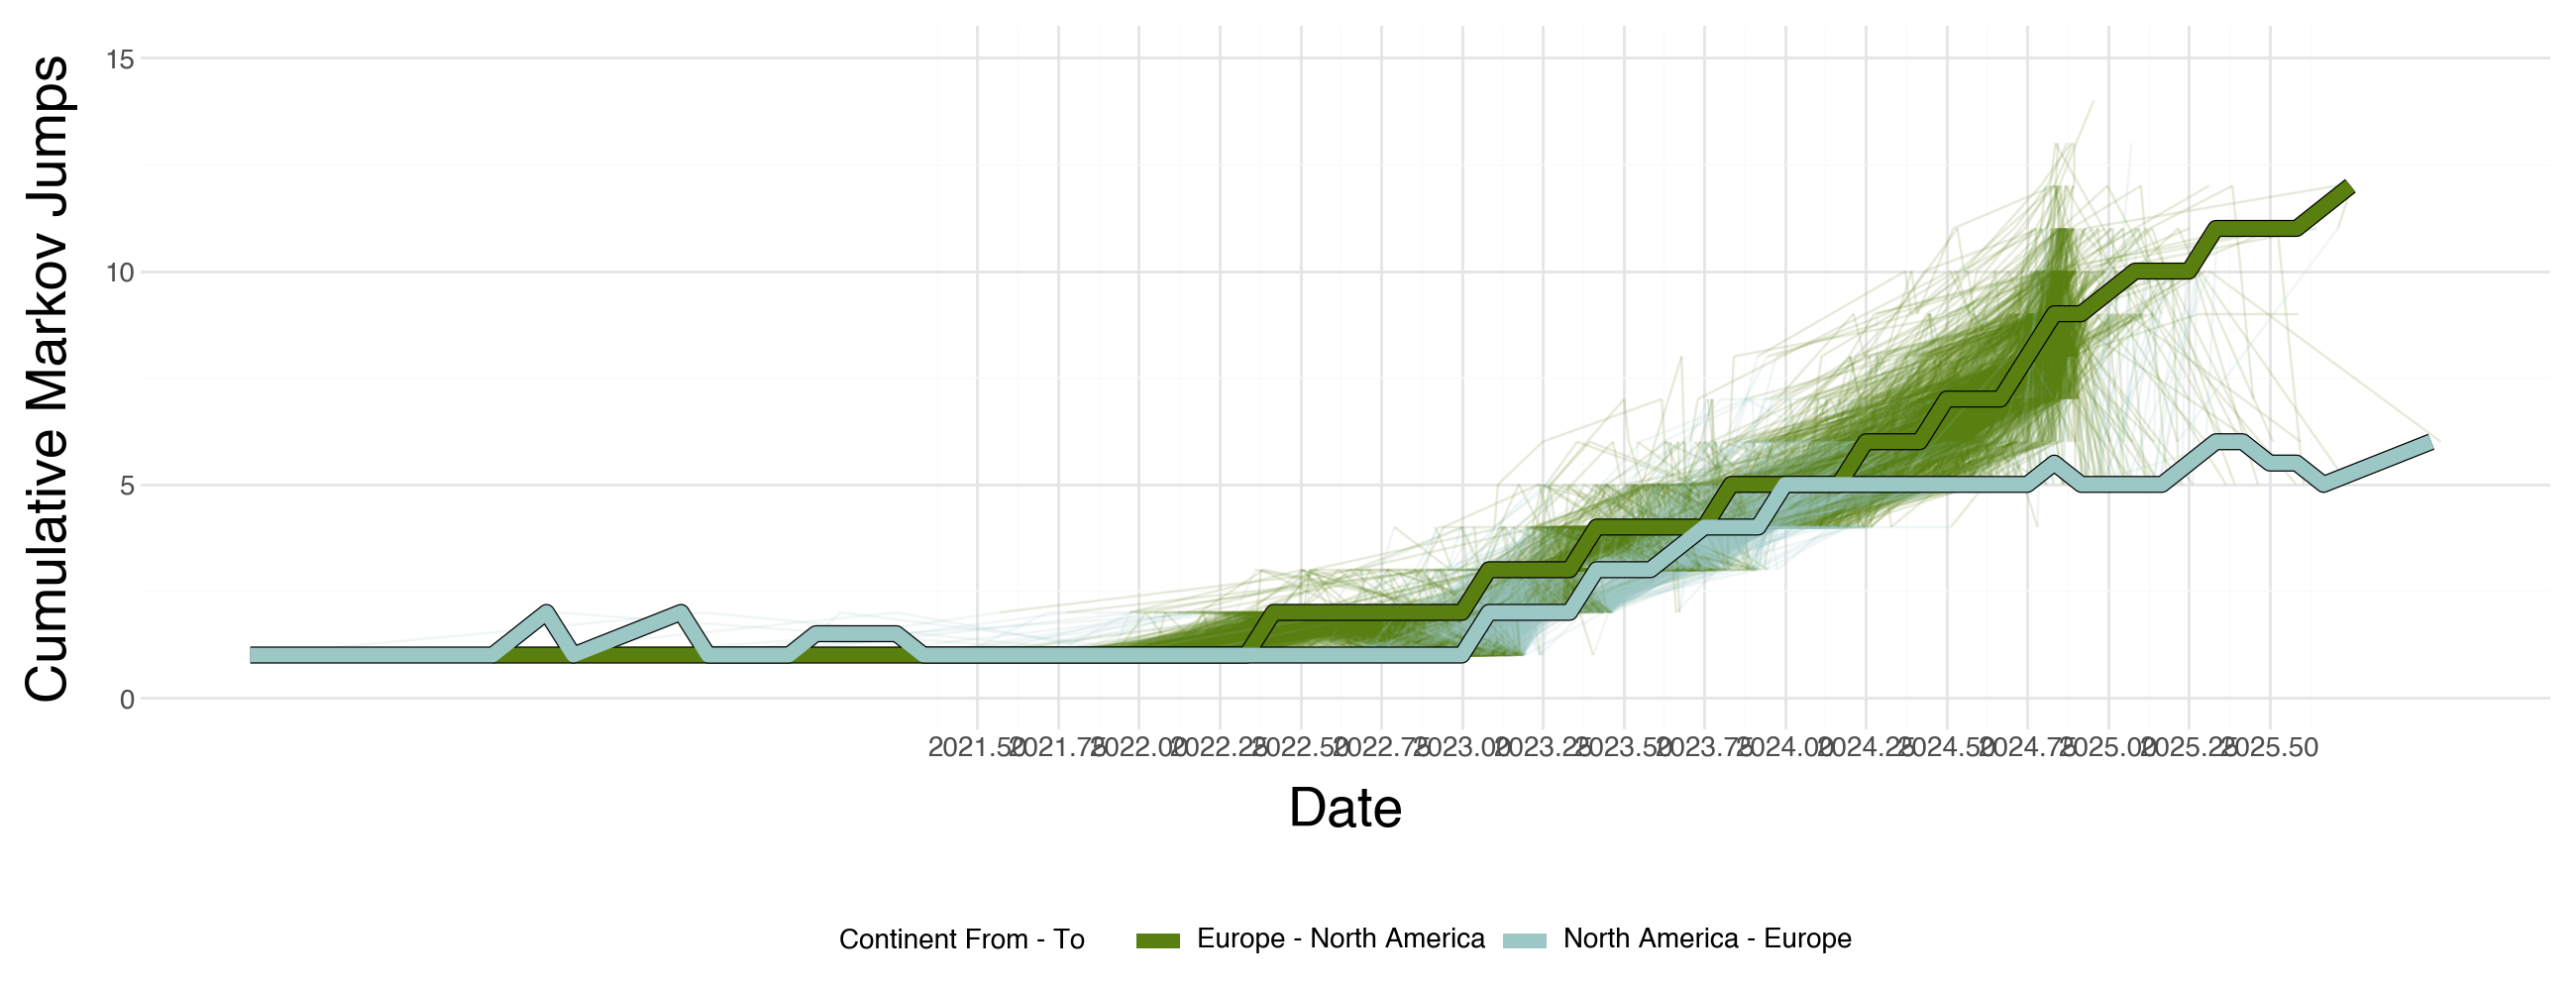

In [25]:
colors3 = {"europe,northamerica":"#587F0F",
          "northamerica,europe":"#9BC7C5"
          }

transition_labels = {"europe,northamerica":"Europe - North America",
        "northamerica,europe":"North America - Europe"
       }

plt3 = (
    ggplot()
    + geom_line(cumul_jumps, aes(x = "date", y = "cumcount", group = "treeNumber", color = "comboContinent"), alpha = 0.15)
    + geom_line(medians, aes(x = "month_bin", y = "cumcount", group = "comboContinent"), size = 3.5, color = "black")
    + geom_line(medians, aes(x = "month_bin", y = "cumcount", color = "comboContinent"), size = 3) # Mean cumulative count of transitions per month 
    + scale_color_manual(values = colors3, labels = transition_labels)
    + scale_x_continuous(breaks = [2021.5, 2021.75, 2022.0, 2022.25, 2022.5, 2022.75, 2023.0, 2023.25, 2023.5, 2023.75, 2024.0, 2024.25, 2024.5, 2024.75, 2025.0, 2025.25, 2025.5])
    + ylim(0, 15)
    + labs(x = "Date", y = "Cumulative Markov Jumps", color = "Continent From - To") 
    + theme_minimal()
    + theme(figure_size = (13, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=10),
           legend_direction="horizontal", legend_position="bottom")
)

plt3.show()

In [199]:
plt3.save("./SERAPHIM/output_plots/cumul_mj_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 13 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/cumul_mj_across_posterior.png


In [17]:
def get_monthyear(y):
    if 2021.665753 <= y < 2021.747945: 
        return "september"
    elif 2021.747945 <= y < 2021.832877: 
        return "october"
    elif 2021.832877 <= y < 2021.915068: 
        return "november"
    elif 2021.915068 <= y < 2022.000000: 
        return "december"
    elif 2022.000000 <= y < 2022.084932: 
        return "january"
    elif 2022.084932 <= y < 2022.161644:
        return "february"
    elif 2022.161644 <= y < 2022.246575:
        return "march"
    elif 2022.246575 <= y < 2022.328767:
        return "april"
    elif 2022.328767 <= y < 2022.413699:
        return "may"
    elif 2022.413699 <= y < 2022.495890:
        return "june"
    elif 2022.495890 <= y < 2022.580822:
        return "july"
    elif 2022.580822 <= y < 2022.665753:
        return "august"
    elif 2022.665753 <= y < 2022.747945:
        return "september"
    elif 2022.747945 <= y < 2022.832877: 
        return "october"
    elif 2022.832877 <= y < 2022.915068:
        return "november"
    elif 2022.915068 <= y < 2023.000000:
        return "december"
    elif 2023.000000 <= y < 2023.084932:
        return "january"
    elif 2023.084932 <= y < 2023.161644:
        return "february"
    elif 2023.161644 <= y < 2023.246575:
        return "march"
    elif 2023.246575 <= y < 2023.328767:
        return "april"
    elif 2023.328767 <= y < 2023.413699:
        return "may"
    elif 2023.413699 <= y < 2023.495890:
        return "june"
    elif 2023.495890 <= y < 2023.580822:
        return "july"
    elif 2023.580822 <= y < 2023.665753:
        return "august"
    elif 2023.665753 <= y < 2023.747945:
        return "september"
    elif 2023.747945 <= y < 2023.832877:
        return "october"
    elif 2023.832877 <= y < 2023.915068:
        return "november"
    elif 2023.915068 <= y < 2024.000000:
        return "december"
    elif 2024.000000 <= y < 2024.084699:
        return "january"
    elif 2024.084699 <= y < 2024.163934:
        return "february"
    elif 2024.163934 <= y < 2024.248634:
        return "march"
    elif 2024.248634 <= y < 2024.330601:
        return "april"
    elif 2024.330601 <= y < 2024.415301:
        return "may"
    elif 2024.415301 <= y < 2024.497268:
        return "june"
    elif 2024.497268 <= y < 2024.581967:
        return "july"
    elif 2024.581967 <= y < 2024.666667:
        return "august"
    elif 2024.666667 <= y < 2024.748634:
        return "september"
    elif 2024.748634 <= y < 2024.833333:
        return "october"
    elif 2024.833333 <= y < 2024.915301:
        return "november"
    elif 2024.915301 <= y < 2025.00000:
        return "december"
    elif 2025.000000 <= y < 2025.084932:
        return "january"
    elif 2025.084932 <= y < 2025.161644:
        return "february"
    elif 2025.161644 <= y < 2025.246575:
        return "march"
    elif 2025.246575 <= y < 2025.328767:
        return "april"
    elif 2025.328767 <= y < 2025.413699:
        return "may"
    elif 2025.413699 <= y < 2025.495890:
        return "june"
    elif 2025.495890 <= y < 2025.580822:
        return "july"
    elif 2025.580822 <= y < 2025.665753:
        return "august"
    elif 2025.665753 <= y < 2025.747945:
        return "september"
    elif 2025.747945 <= y < 2025.832877:
        return "october"
    elif 2025.832877 <= y < 2025.915068:
        return "november"
    elif 2025.915068 <= y < 2026.00000:
        return "december"
    else:
        return "unknown"

In [18]:
def get_seasonyear(y):
    if y <= 2021.96986: # late autumn 2021
        return "autumn"
    elif 2021.96986 < y <= 2022.21096: # winter 2021-22
        return "winter"
    elif 2022.21096 < y <= 2022.46575: # spring 2022
        return "spring"
    elif 2022.46575 < y <= 2022.72055: # summer 2022
        return "summer"
    elif 2022.72055 < y <= 2022.96712: # autumn 2022
        return "autumn"
    elif 2022.96712 < y <= 2023.21096: # winter 2022-23
        return "winter"
    elif 2023.21096 < y <= 2023.46575: # spring 2023
        return "spring"
    elif 2023.46575 < y <= 2023.72329: # summer 2023
        return "summer"
    elif 2023.72329 < y <= 2023.96712: # autumn 2023
        return "autumn"
    elif 2023.96712 < y <= 2024.21038: # winter 2023-24
        return "winter"
    elif 2024.21038 < y <= 2024.46448: # spring 2024
        return "spring"
    elif 2024.46448 < y <= 2024.72131: # summer 2024
        return "summer"
    elif 2024.72131 < y <= 2024.96721: # autumn 2024
        return "autumn"
    elif 2024.96721 < y <= 2025.213699: # winter 2024-25
        return "winter"
    elif 2025.213699 < y <= 2025.468493: # spring 2025
        return "spring"
    elif 2025.468493 < y <= 2025.723288: # summer 2025
        return "summer"
    elif 2025.723288 < y <= 2025.969863: # autumn 2025
        return "autumn"
    elif 2025.969863 < y <= 2026.0: # winter 2024-26
        return "winter"
    else:
        return "unknown"

In [19]:
# To plot the probability of Markov jumps occuring in each month

permonth_rows = []

mask = ["europe,northamerica","northamerica,europe"]


for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
    if combo in mask:
        df["month"] = df["date"].apply(get_monthyear)
        df["season"] = df["date"].apply(get_seasonyear)
        df["total_trans"] = len(df)
        for month, df2 in df.groupby("month"):
            df.loc[df["month"] == month, "trans_per_month"] = len(df2)
        for season, df2 in df.groupby("season"):
            df.loc[df["season"] == season, "trans_per_season"] = len(df2)
        df["prop_per_month"] = df["trans_per_month"] / df["total_trans"]
        df["prop_per_seas"] = df["trans_per_season"] / df["total_trans"]
        columns = ["treeNumber", "date", "comboContinent", "month", "season", 
                   "total_trans", "trans_per_month", "trans_per_season", 
                   "prop_per_month", "prop_per_seas"]
        permonth_rows.append(df.loc[:, columns])
    else:
       pass


permonth = pd.concat(permonth_rows)

# print(permonth)

In [20]:
month_order = ["january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december"]

permonth["month"] = pd.Categorical(permonth["month"], categories=month_order, ordered=True)

/var/folders/8z/j5vh6t990rj40lqqxtsr69z00000gp/T/ipykernel_24432/1387571961.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.


In [21]:
# To plot the counts per month across the distribution 

transition_counts = permonth.groupby(["month", "comboContinent"])["trans_per_month"].quantile([0.025, 0.5, 0.975]).unstack().rename(columns={0.025: "lower", 0.5: "median", 0.975: "upper"})
transition_counts = transition_counts.reset_index().rename({"month":"month", "comboContinent":"comboContinent"})
transition_counts["month"] = pd.Categorical(transition_counts["month"], categories=month_order, ordered=True)
print(permonth)

    treeNumber         date       comboContinent     month  season  \
0            1  2023.040812  europe,northamerica   january  winter   
2            1  2023.474435  europe,northamerica      june  summer   
7            1  2022.080602  europe,northamerica   january  winter   
18           1  2023.255891  europe,northamerica     april  spring   
19           1  2024.790202  europe,northamerica   october  autumn   
..         ...          ...                  ...       ...     ...   
19         899  2023.616933  northamerica,europe    august  summer   
9          900  2023.625955  northamerica,europe    august  summer   
19         900  2022.875702  northamerica,europe  november  autumn   
21         900  2023.623217  northamerica,europe    august  summer   
22         900  2023.285337  northamerica,europe     april  spring   

    total_trans  trans_per_month  trans_per_season  prop_per_month  \
0            10              3.0               3.0            0.30   
2            10    

In [33]:
permonth_quant = (permonth.groupby(["month", "comboContinent"])["trans_per_month"].quantile([0.025, 0.5, 0.975])
             .unstack().rename(columns={0.025: "lower", 0.5: "median", 0.975: "upper"}))
permonth_quant = permonth_quant.reset_index()
print(permonth_quant)

        month       comboContinent  lower  median  upper
0     january  europe,northamerica    1.0     1.0    3.0
1     january  northamerica,europe    1.0     1.0    2.0
2    february  europe,northamerica    1.0     1.0    3.0
3    february  northamerica,europe    1.0     1.0    2.0
4       march  europe,northamerica    1.0     2.0    4.0
5       march  northamerica,europe    1.0     1.0    3.0
6       april  europe,northamerica    1.0     2.0    3.0
7       april  northamerica,europe    1.0     1.0    2.0
8         may  europe,northamerica    1.0     2.0    3.0
9         may  northamerica,europe    1.0     1.0    2.0
10       june  europe,northamerica    1.0     1.0    3.0
11       june  northamerica,europe    1.0     1.0    2.0
12       july  europe,northamerica    1.0     1.0    3.0
13       july  northamerica,europe    1.0     1.0    2.0
14     august  europe,northamerica    1.0     1.0    3.0
15     august  northamerica,europe    1.0     1.0    2.0
16  september  europe,northamer

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'x' is already present.
Adding another scale for 'x',
which will replace the existing scale.



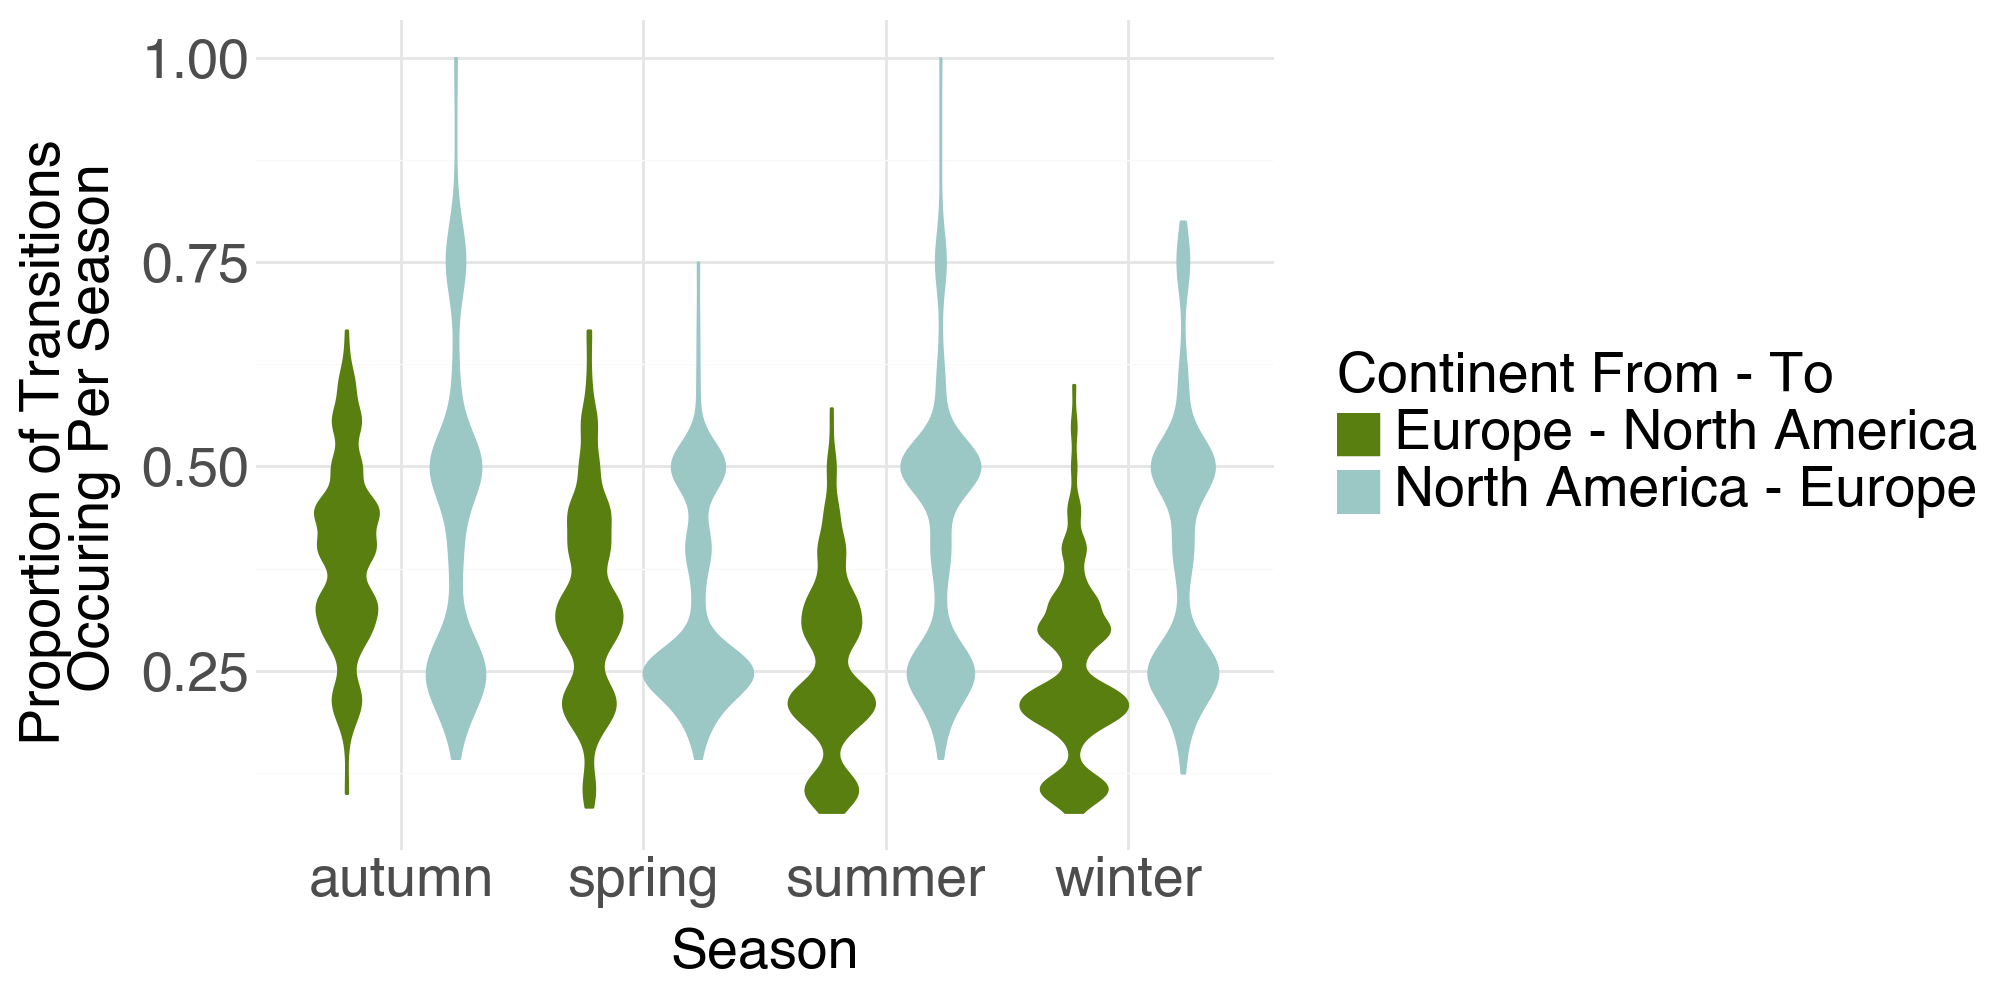

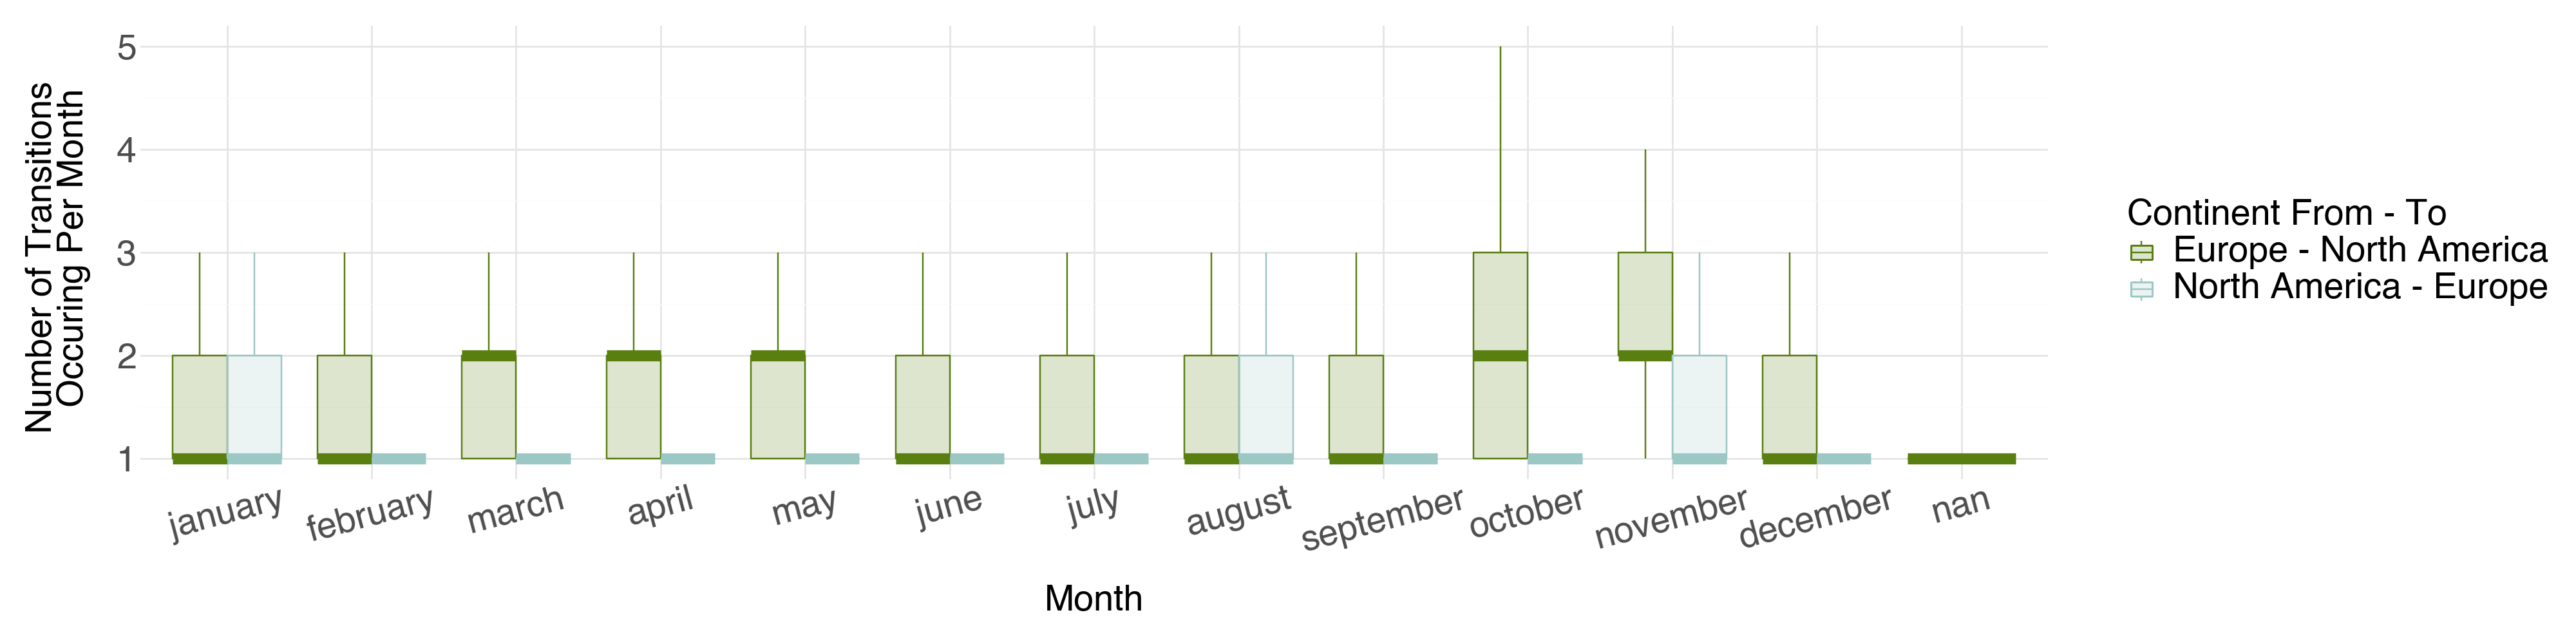

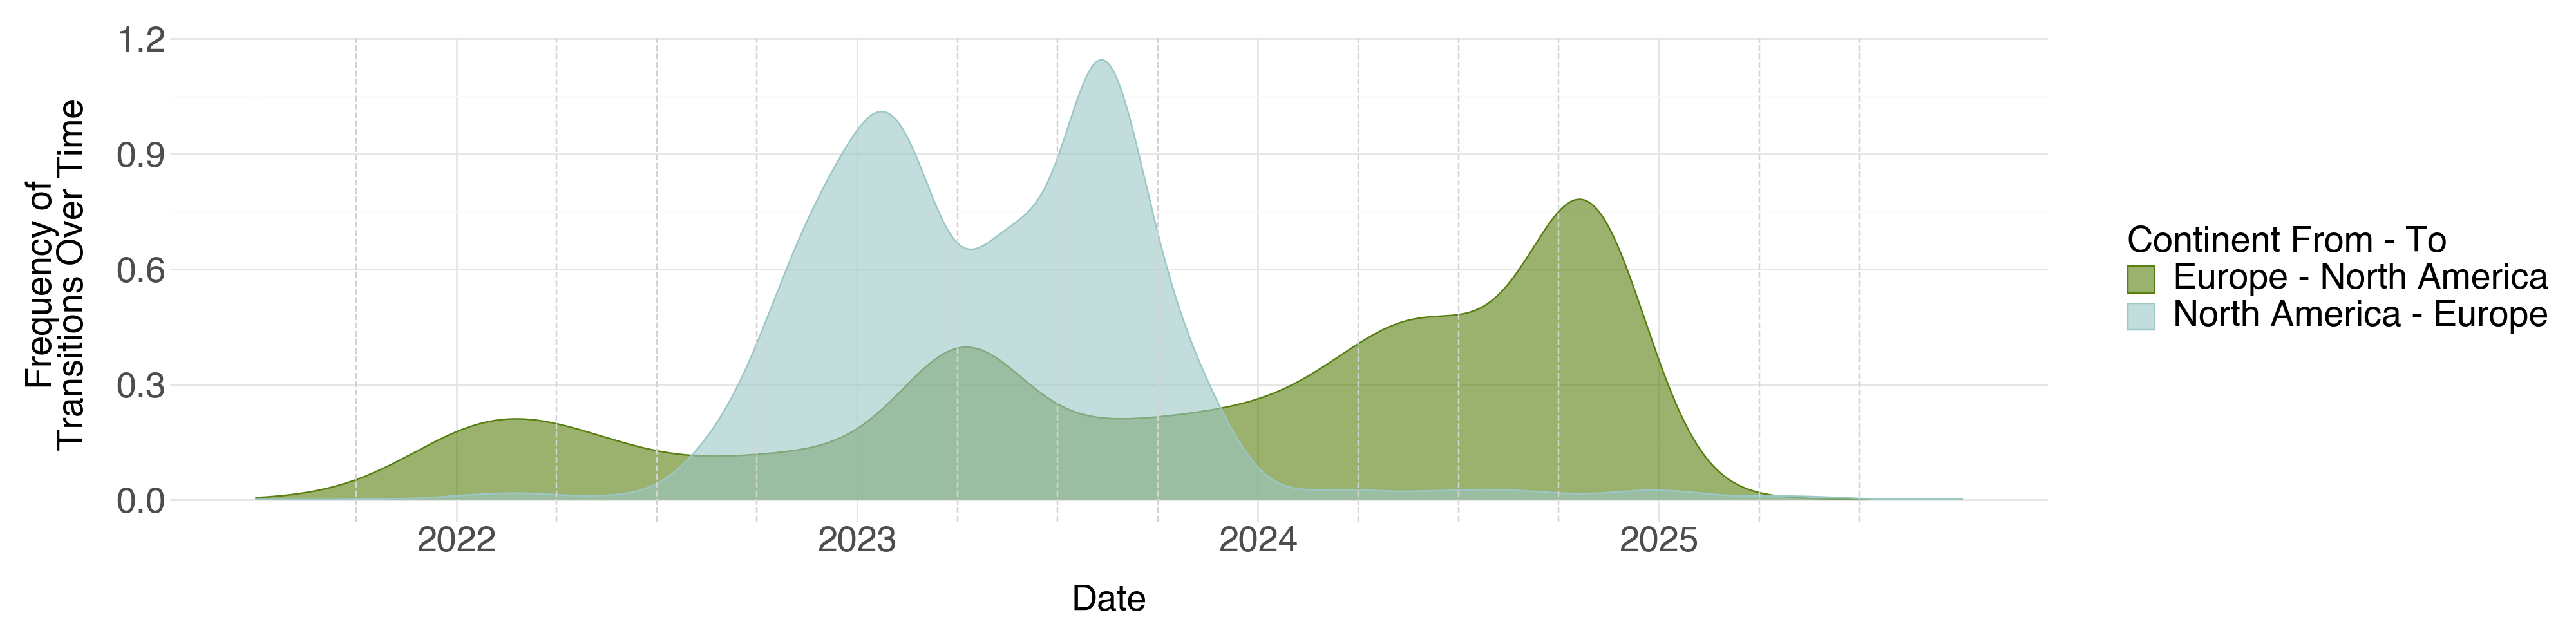

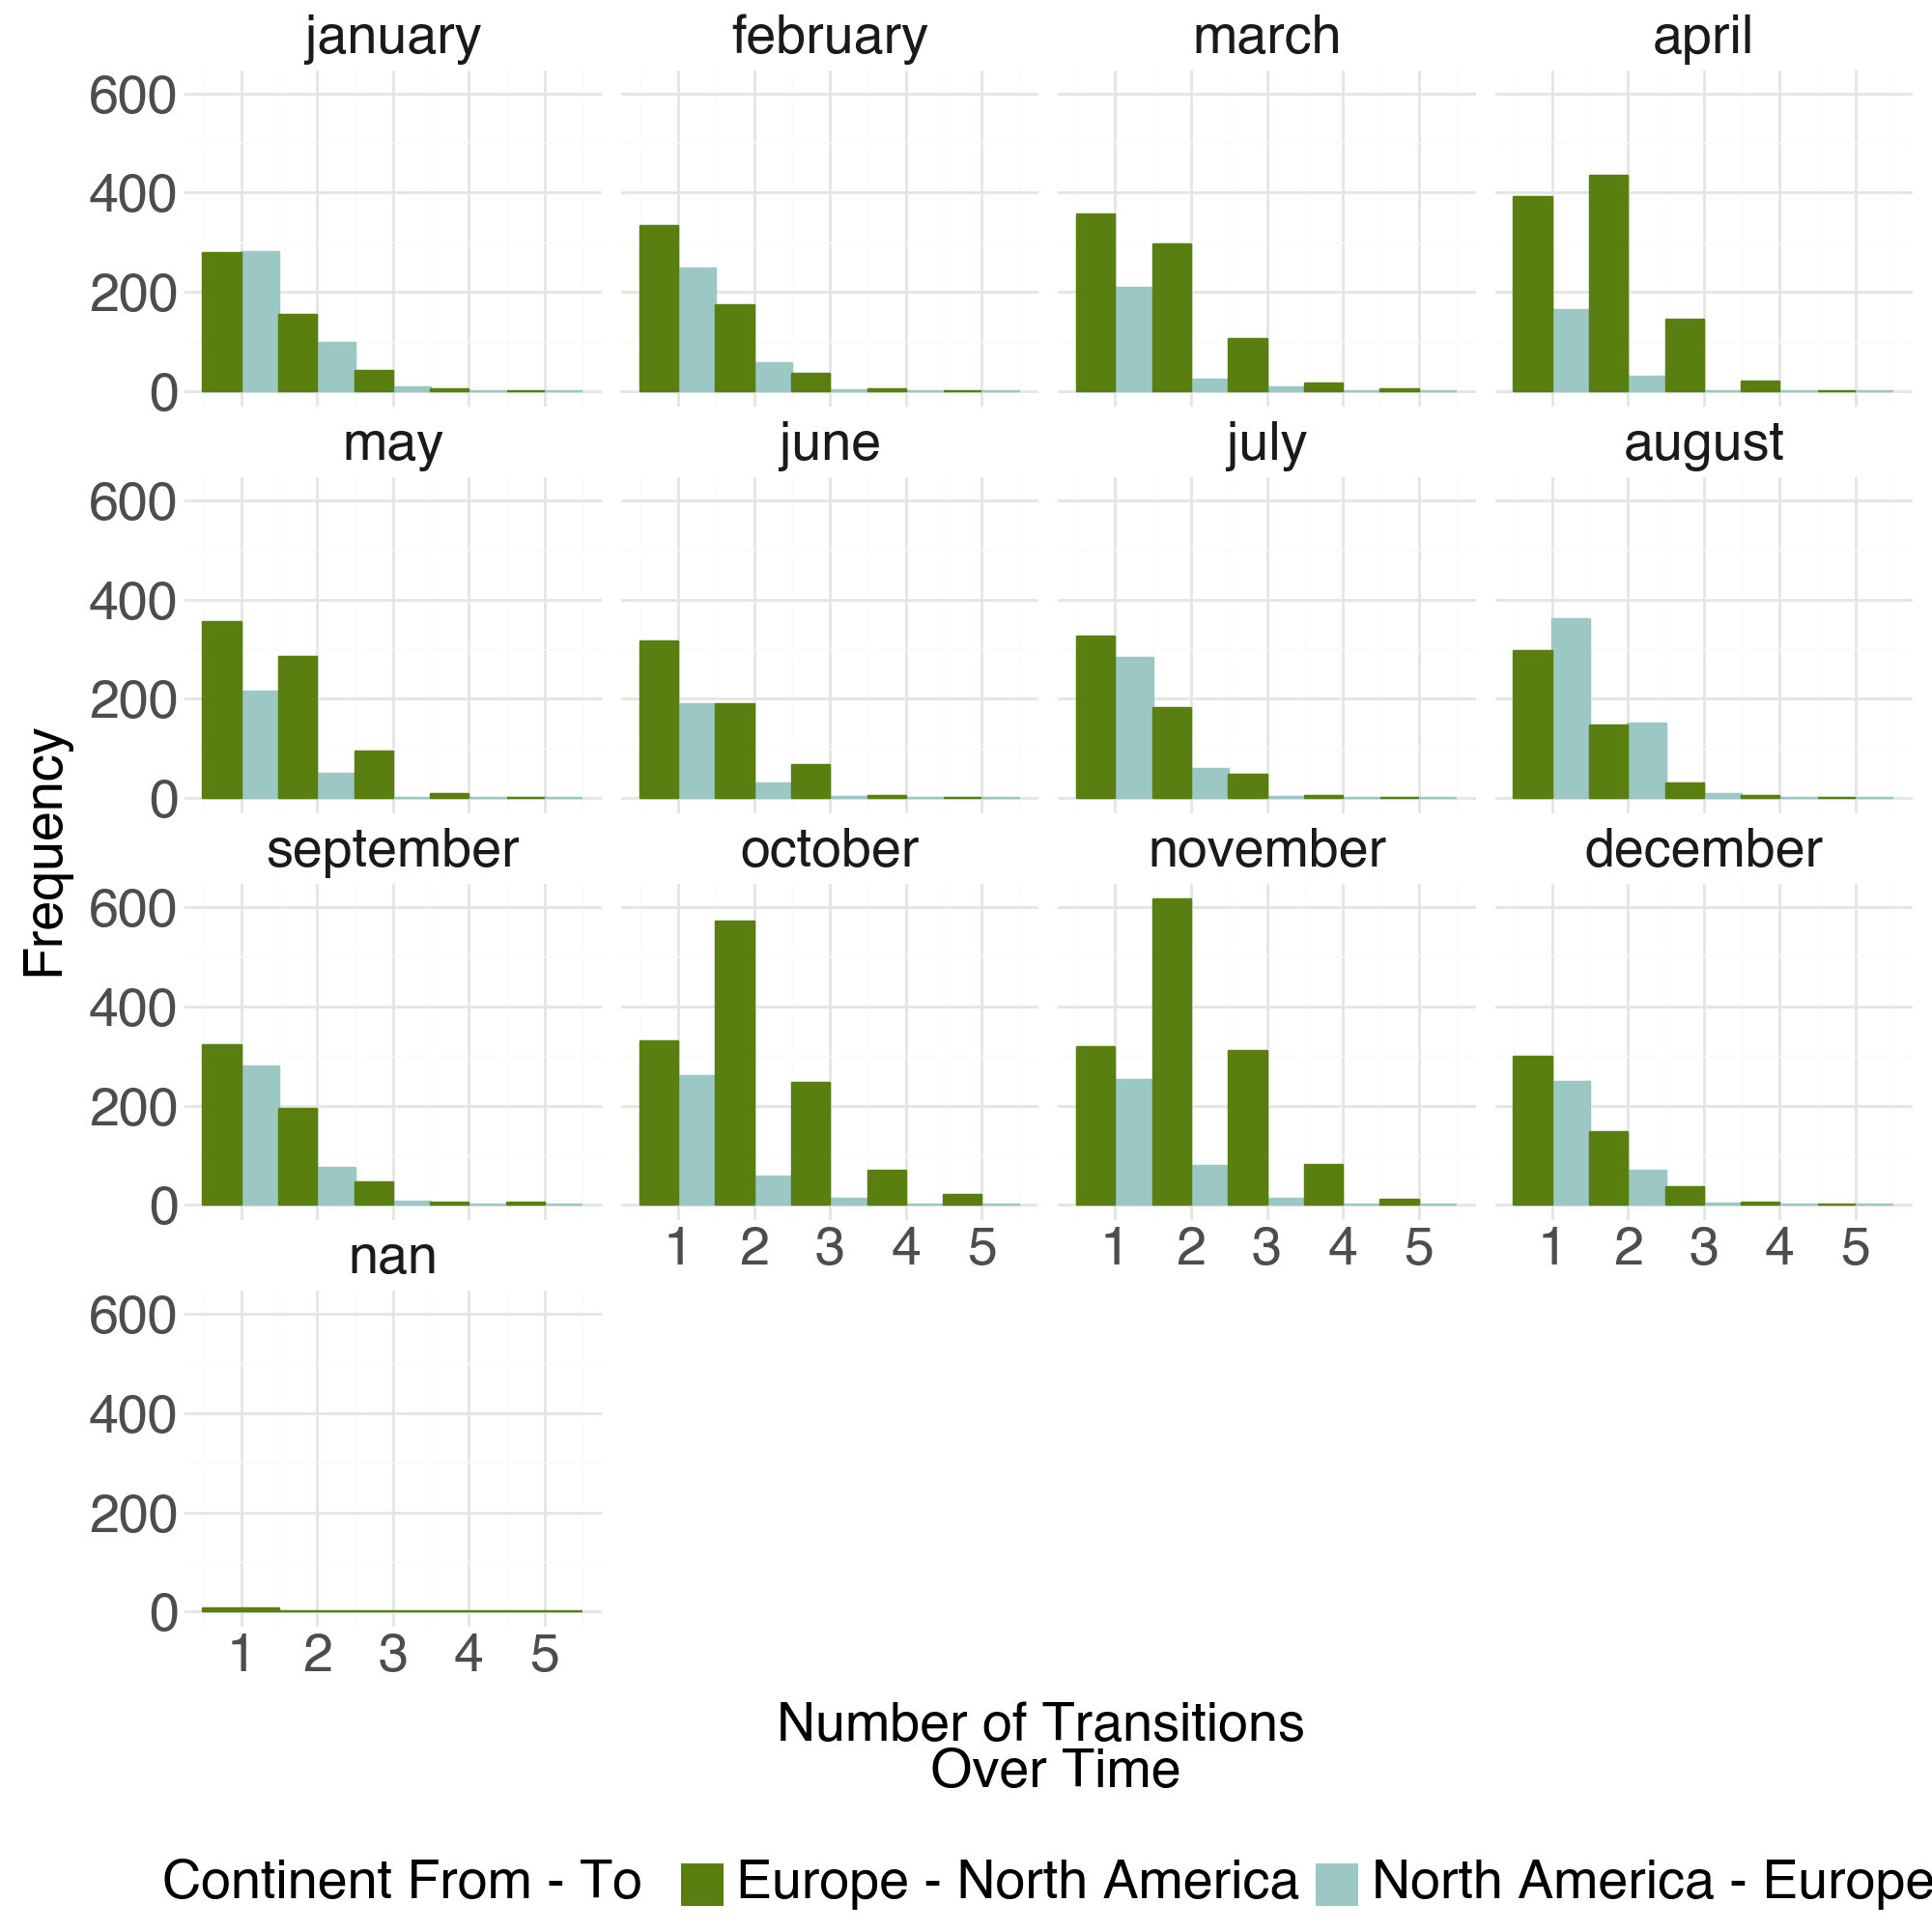

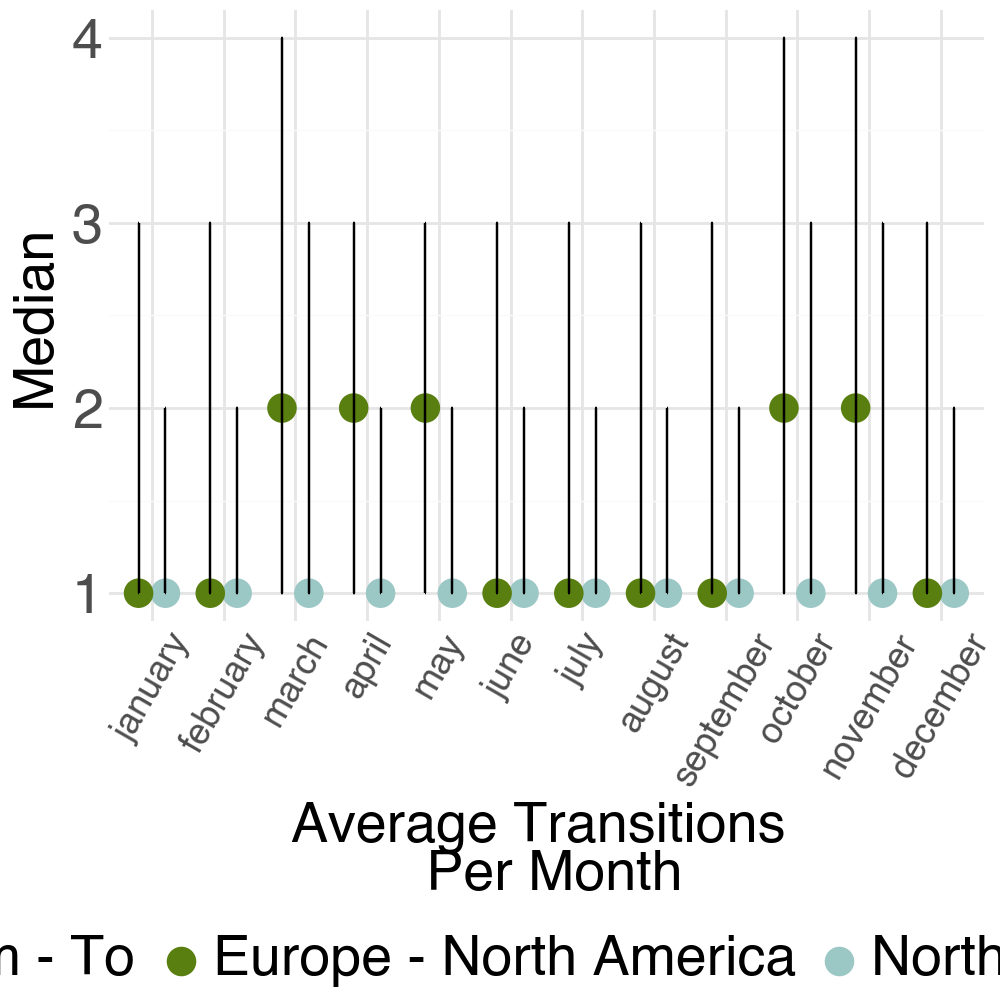

In [42]:
plt4 = (
    ggplot(permonth, aes(x = "season", y = "prop_per_seas", fill = "comboContinent", color = "comboContinent"))
    + geom_violin()
    # + geom_point(position = "jitter")
    # + geom_col(position = "dodge")
    # + labs(x = "Month", y = "Proportion of Transitions Occuring Per Month", fill = "Continent From - To", color = "Continent From - To")
    + labs(x = "Season", y = "Proportion of Transitions \n Occuring Per Season", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
)

plt4_alt1 = (
    ggplot(permonth, aes(x = "month", y = "trans_per_month", fill = "comboContinent", color = "comboContinent"))
    + geom_boxplot(position = "dodge", alpha = 0.2, fatten = 7, outlier_alpha = 0)
    # + geom_jitter(alpha = 0.15, position=position_jitterdodge(dodge_width=0.7, jitter_width = 0.5, jitter_height=0.15))
    + labs(x = "Month", y = "Number of Transitions \n Occuring Per Month", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + theme_minimal()
    + theme(figure_size = (20, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20),
           axis_text_x = element_text(rotation = 15))
)

plt4_alt2 = (
    ggplot(permonth, aes(x = "date", fill = "comboContinent", color = "comboContinent"))
    + geom_density(alpha = 0.6)
    + labs(x = "Date", y = "Frequency of \n Transitions Over Time", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + geom_vline(xintercept = [2021.75, 2022.25, 2022.5, 2022.75,
                               2023.25, 2023.5, 2023.75,
                               2024.25, 2024.5, 2024.75, 2025.25, 2025.5
                              ], linetype = "dashed", color = "lightgrey")
    + theme_minimal()
    + theme(figure_size = (20, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
)

plt4_alt3 = (
    ggplot(permonth, aes(x = "trans_per_month", fill = "comboContinent", color = "comboContinent"))
    + geom_histogram(position = "dodge", binwidth = 1)
    + facet_wrap("month")
    + labs(x = "Number of Transitions \n Over Time", y = "Frequency", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + theme_minimal()
    + xlim(-1, 6)
    + scale_x_continuous(breaks=np.arange(-1, 7, 1))
    + theme(figure_size = (10, 10), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20),
           legend_direction="horizontal", legend_position="bottom")
)

plt4_alt4 = (
    ggplot(permonth_quant, aes(x = "month", y = "median", color = "comboContinent"))
    + geom_point(stat = "identity", size = 5, position=position_dodge(width=0.75))
    + geom_errorbar(aes(ymin = "lower", ymax = "upper", group = "comboContinent"), width = 0.05, color = "black", position=position_dodge(width=0.75))
    + labs(x = "Average Transitions \n Per Month", y = "Median", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + theme_minimal()
    + theme(figure_size = (5, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20),
            axis_text_x = element_text(rotation = 60, size = 13), legend_direction="horizontal", legend_position="bottom")
)

plt4.show()
plt4_alt1.show()
plt4_alt2.show()
plt4_alt3.show()
plt4_alt4.show()

In [43]:
# plt4.save("./SERAPHIM/output_plots/mj_permonth_across_posterior.png", format = "png", dpi = 750)
plt4.save("./SERAPHIM/output_plots/mj_perseason_across_posterior.png", format = "png", dpi = 750)
plt4_alt2.save("./SERAPHIM/output_plots/mj_perseason_across_posterior_v2.png", format = "png", dpi = 750)
plt4_alt3.save("./SERAPHIM/output_plots/mj_perseason_across_posterior_v3.png", format = "png", dpi = 750)
plt4_alt4.save("./SERAPHIM/output_plots/mj_perseason_across_posterior_v4.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_perseason_across_posterior.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_perseason_across_posterior_v2.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_perseason_across_posterior_v3.png
/Users/claramal/miniconda3/

In [232]:
# To plot number of transitions per year
# Chat GPT helped a lot with this, mostly because I just cannot figure out how to bend my brain around this

transition_peryr_rows = []

# get all possible combos in the dataset
all_combos = treejumps["comboContinent"].unique()

for (tree, year), df in treejumps.groupby(["treeNumber", "year"]):
    counts = df["comboContinent"].value_counts()

    # add missing combos with count = 0
    counts = counts.reindex(all_combos, fill_value=0)

    for combo, count in counts.items():
        if combo == "northamerica,northamerica":
            continue
        else:
            # avg_count = 
            transition_peryr_rows.append({"tree":tree, "year": year, "combo": combo, "count": count})
        # print(tree, year, combo, count)

transition_peryr = pd.DataFrame(transition_peryr_rows)

transition_peryr["avg_count"] = transition_peryr.groupby(["tree", "combo"])["count"].transform("mean")

In [233]:
# Chat GPT made this for me after I asked it to fix the following loop

# for combo in transition_peryr_quantiles: 
#     quantiles = transition_peryr.loc["combo" == combo, "avg_count"].quantile([0.025, 0.5, 0.975]).rename({0.025: "lower", 0.5: "median", 0.975: "upper"}) 
#     print(quantiles)

quantiles = (transition_peryr.groupby("combo")["avg_count"].quantile([0.025, 0.5, 0.975])
             .unstack().rename(columns={0.025: "lower", 0.5: "median", 0.975: "upper"}))

In [234]:
quantiles = quantiles.reset_index()

In [235]:
quantiles["labels"] = quantiles["combo"].str.split(",",expand = True)[0].map(labels_dict) + " - " + quantiles["combo"].str.split(",",expand = True)[1].map(labels_dict)
print(quantiles)

                 combo  lower  median     upper                  labels
0          asia,europe    0.0    0.00  0.000000           Asia - Europe
1    asia,northamerica    0.0    0.00  0.000000    Asia - North America
2          europe,asia    0.0    0.25  0.333333           Europe - Asia
3  europe,northamerica    1.8    2.25  3.250000  Europe - North America
4    northamerica,asia    0.0    0.00  0.250000    North America - Asia
5  northamerica,europe    0.8    1.00  1.500000  North America - Europe


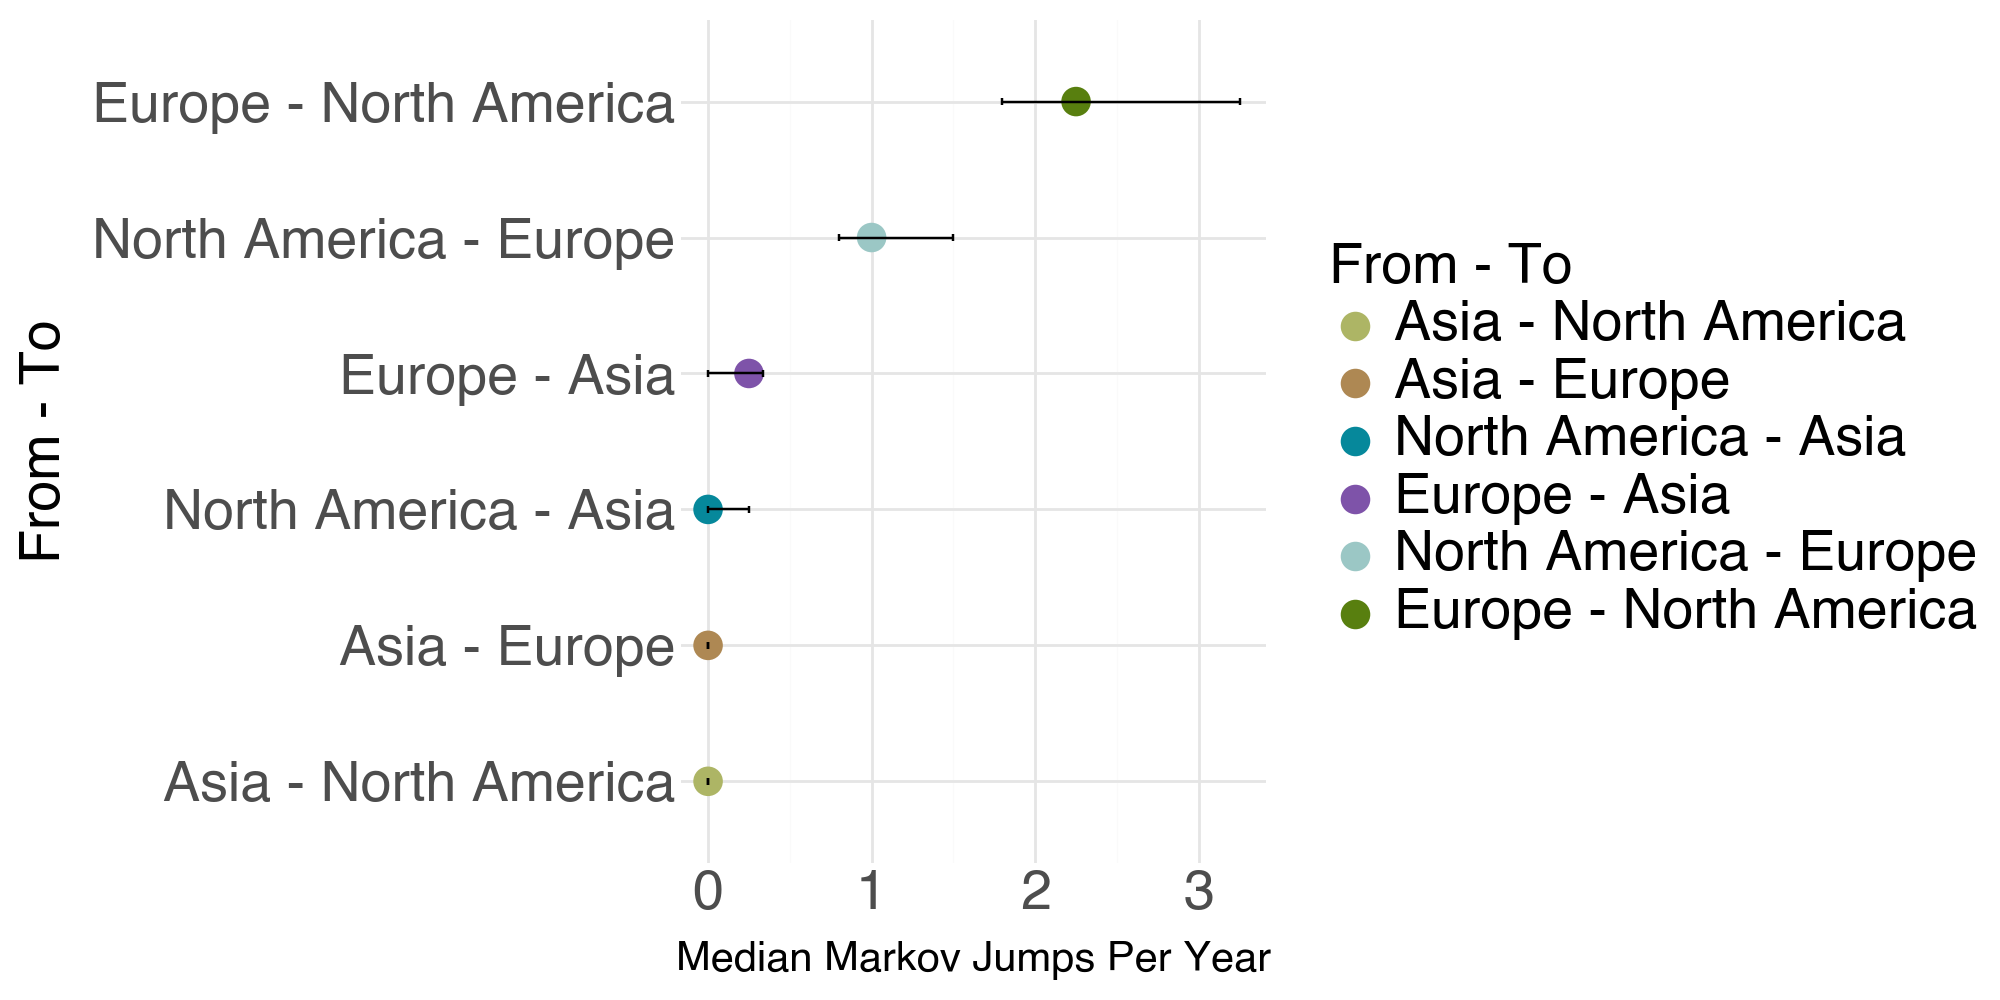

In [237]:
level = ["Asia - North America", "Asia - Europe", "North America - Asia", 
         "Europe - Asia", "North America - Europe", "Europe - North America"
        ]

# Put labels in order of largest to smallest (upper)
quantiles["labels"] = pd.Categorical(quantiles["labels"], categories=level, ordered=True)


plt5 = (
    ggplot(quantiles, aes(x = "labels", y = "median", color = "labels"))
    + geom_point(stat = "identity", size = 5)
    + geom_errorbar(aes(ymin = "lower", ymax = "upper"), width = 0.05, color = "black")
    + scale_color_manual(colors)
    + labs(x = "From - To", y = "Median Markov Jumps Per Year", color = "From - To")
    + coord_flip()
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 15), axis_title_y = element_text(size = 20), text=element_text(size=20)) # axis_text_x=element_text(rotation=60)
)

plt5.show()

In [238]:
plt5.save("./SERAPHIM/output_plots/mj_med-per-year.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_med-per-year.png


In [215]:
# Bayes factor for transitions

# read in Bayes analysis from spread
bayes = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/region_bayes.txt.txt", sep = "\t")

# read in rates combined log file
# rates_combined = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/A6_concat-genome_traits_gnl-eu_202603-10_combined.region.rates.log",sep = "\t").T
# rates_combined.loc[rates_combined.index.astype(str).str.contains("indicators"), "mean_post_prob"] = rates_combined.mean(axis = 1) # mean indicators matches posterior probability
# indicators_combined = rates_combined.loc[rates_combined.index.astype(str).str.contains("indicators")].reset_index()

# I was not able to figure out how to compute the correct mean from the combined log file
# So I assigned location labels by hand
bayes["FROM_CONTINENT"] = bayes["FROM_LABEL"].map(continent_dict)
bayes["TO_CONTINENT"] = bayes["TO_LABEL"].map(continent_dict)
bayes["labels"] = bayes["FROM_CONTINENT"].map(labels_dict) + " - " + bayes["TO_CONTINENT"].map(labels_dict)

# Remove within-north-america transitions (because we're not interested in them here)
bayes_cross_continent = bayes[~(bayes["labels"] == "North America - North America")]

# print(bayes_cross_continent)

/var/folders/8z/j5vh6t990rj40lqqxtsr69z00000gp/T/ipykernel_91824/3832092837.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/claramal/miniconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


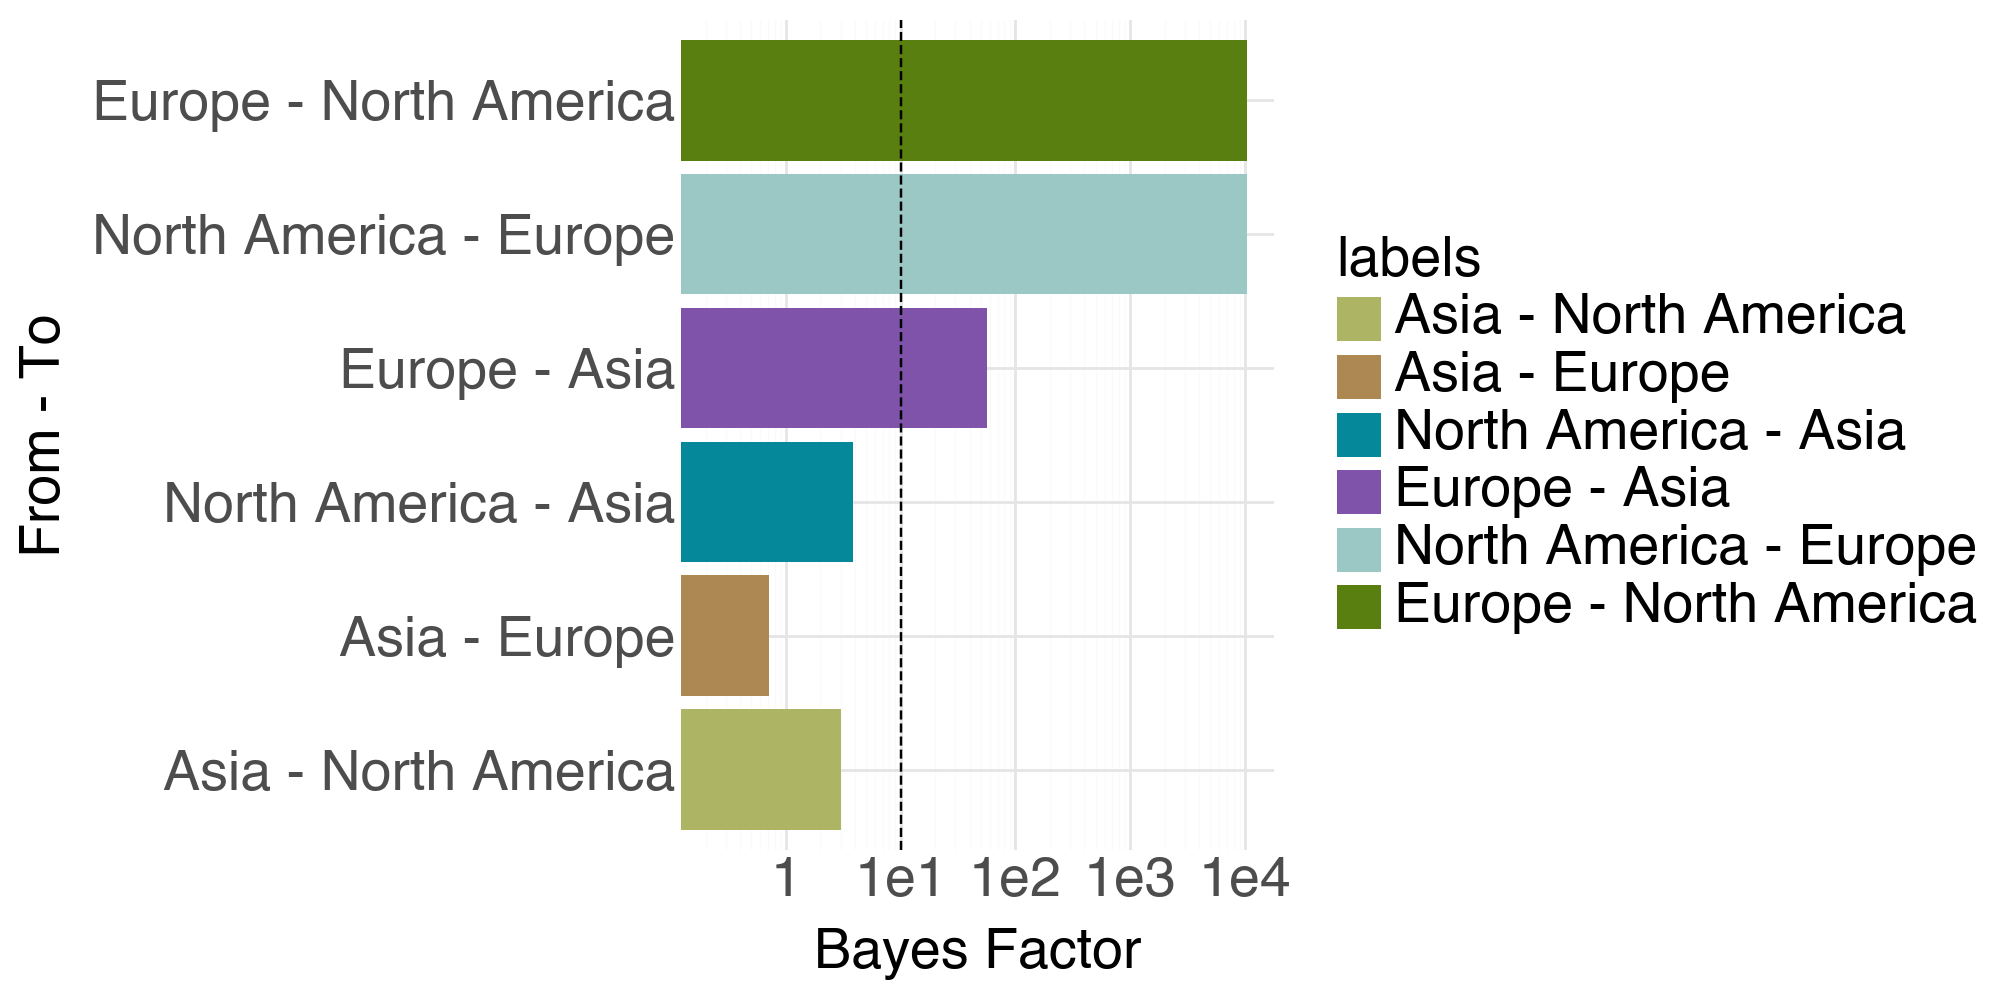

In [216]:
level = ["Asia - North America", "Asia - Europe", "North America - Asia", 
         "Europe - Asia", "North America - Europe", "Europe - North America"
        ]

# Put labels in order of largest to smallest (upper)
bayes_cross_continent["labels"] = pd.Categorical(bayes_cross_continent["labels"], categories=level, ordered=True)


plt6 = (
    ggplot(bayes_cross_continent, aes(x = "labels", y = "BAYES_FACTOR", fill = "labels"))
    + geom_col(stat = "identity")
    + scale_fill_manual(colors)
    + labs(x = "From - To", y = "Bayes Factor", color = "From - To")
    + coord_flip()
    + scale_y_log10()
    + geom_hline(yintercept = 1e1, linetype = "dashed")
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20)) # axis_text_x=element_text(rotation=60)
)

plt6.show()

In [217]:
plt6.save("./SERAPHIM/output_plots/bayes_factor_region.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/bayes_factor_region.png
/Users/claramal/miniconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


In [241]:
(plt5 | plot_spacer() | plt62)

NameError: name 'plot_spacer' is not defined

In [ ]:
# How might I calculate Markov rewards?